Hyperparameters:

settings chosen before training
control model behavior/complexity

Important RF hyperparameters:

n_estimators → number of trees

max_depth → tree complexity

min_samples_split → splitting strictness

min_samples_leaf → minimum leaf size

max_features → features checked per split

Main concept:

Hyperparameter tuning = adjusting model settings to improve generalization and reduce overfitting

In [1]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

df = pd.read_csv('clean_titanic.csv')
X = df.drop('Survived', axis=1)
y = df['Survived']

param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [4, 6, 8, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print("Best params:", grid_search.best_params_)
print("Best CV score:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV score: 0.8328


GridSearchCV

Goal:

Automatically find the best hyperparameters

Instead of manually trying values one by one.

GridSearchCV:


tries all hyperparameter combinations


uses cross-validation for reliable evaluation


finds best-performing settings automatically


Important concepts:


cv=5 → 5-fold cross validation


n_jobs=-1 → use all CPU cores


more combinations = slower but more thorough


Main concept:
Hyperparameter tuning improves model generalization by finding better model settings objectively

In [2]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

cols = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
print(results_df[cols].head(10).to_string())

                                                                                       params  mean_test_score  std_test_score  rank_test_score
89   {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}         0.832773        0.021723                1
88   {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}         0.832773        0.021723                1
91    {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}         0.831662        0.023476                3
94    {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}         0.831662        0.023476                3
95    {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}         0.831662        0.023476                3
71      {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}         0.831662        0.020917          

This code:


views all GridSearch results


sorts best models first


compares both accuracy and stability


Important metrics:


mean_test_score → average performance


std_test_score → consistency across folds


Main concept:
Reliable models should perform consistently, not just achieve one lucky high score

In [3]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators':      randint(100, 500),
    'max_depth':         [4, 5, 6, 7, 8, 10, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', None],
}

rand_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand_search.fit(X, y)

print("Best params:", rand_search.best_params_)
print("Best CV score:", round(rand_search.best_score_, 4))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 269}
Best CV score: 0.8361


Quick Summary
RandomizedSearchCV:


tests random hyperparameter combinations


faster alternative to GridSearch


usually finds strong results efficiently


Important concepts:


n_iter → number of random combinations tried


randint() → sample random values from range


still uses cross-validation


Main concept:
Smart random search can achieve near-optimal tuning with far less computation than exhaustive search

In [4]:
print("GridSearch best:       ", round(grid_search.best_score_, 4))
print("RandomizedSearch best: ", round(rand_search.best_score_, 4))
print()
print("GridSearch best params:      ", grid_search.best_params_)
print("RandomizedSearch best params:", rand_search.best_params_)

GridSearch best:        0.8328
RandomizedSearch best:  0.8361

GridSearch best params:       {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
RandomizedSearch best params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 269}


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_params = grid_search.best_params_

best_rf = RandomForestClassifier(**best_params, random_state=42)
best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_val)
print("Tuned RF val accuracy:", round(accuracy_score(y_val, y_pred), 4))
print(classification_report(y_val, y_pred))

Tuned RF val accuracy: 0.8156
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



This code:


takes best hyperparameters


retrains optimized Random Forest


evaluates tuned model on validation data


Main concept:
Hyperparameter tuning improves generalization by finding better model complexity/settings, not by memorizing data

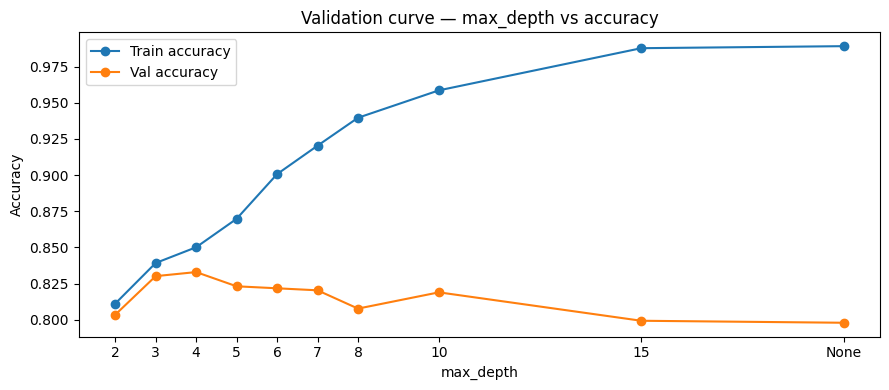

In [6]:
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
import numpy as np

depths = [2, 3, 4, 5, 6, 7, 8, 10, 15, None]
depths_numeric = [d if d is not None else 20 for d in depths]

train_scores, val_scores = validation_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train, y_train,
    param_name='max_depth',
    param_range=depths,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores,   axis=1)

plt.figure(figsize=(9, 4))
plt.plot(depths_numeric, train_mean, label='Train accuracy', marker='o')
plt.plot(depths_numeric, val_mean,   label='Val accuracy',   marker='o')
plt.xticks(depths_numeric, [str(d) for d in depths])
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Validation curve — max_depth vs accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Validation curve:


tests model performance across hyperparameter values


compares train vs validation accuracy


visually shows underfitting and overfitting


Key interpretation:


low both → underfitting


high train + low val → overfitting


peak validation score → best complexity


Main concept:
Best models balance learning and generalization, not maximum training accuracy